**Climate Visibility – JFK Airport Fog Analysis & Prediction System**

"Analyze visibility (fog/mist) by correlating it with climate factors such as temperature, humidity, dew point, wind, and precipitation to develop an accurate prediction model for issuing low-visibility alerts."

**Required libraries**


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#data load 
df = pd.read_csv('jfk_weather_cleaned.csv')

#baisc info
print("--- Data Info ---")
print(df.info())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  object 
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
 10  Precip            75083 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 6.3+ MB
None

--- Missing Values ---
DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection    

In [3]:
#check for null values
print("\n --- Missing Values ---")
print(df.isnull().sum())


 --- Missing Values ---
DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64


In [4]:
#statistical summary
print("\n --- Descriptive Statistics ---")
print(df.describe())


 --- Descriptive Statistics ---
         VISIBILITY  DRYBULBTEMPF  WETBULBTEMPF  DewPointTempF  \
count  75083.000000  75083.000000  75083.000000   75083.000000   
mean       9.211896     55.355527     49.327544      42.424024   
std        2.202311     17.394334     16.182867      19.577957   
min        0.000000      1.000000     -1.000000     -19.000000   
25%       10.000000     42.000000     36.000000      27.000000   
50%       10.000000     56.000000     50.000000      44.000000   
75%       10.000000     70.000000     64.000000      59.000000   
max       14.000000    102.000000     85.000000      84.000000   

       RelativeHumidity     WindSpeed  WindDirection  StationPressure  \
count      75083.000000  75083.000000   75083.000000     75083.000000   
mean          64.812075     11.253240     196.550751        30.005579   
std           19.898962      6.101048     107.692804         0.235172   
min            8.000000      0.000000       0.000000        28.520000   
25%    

In [5]:
df.columns

Index(['DATE', 'VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF',
       'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure',
       'SeaLevelPressure', 'Precip'],
      dtype='object')

In [6]:
print(df.head())

                  DATE  VISIBILITY  DRYBULBTEMPF  WETBULBTEMPF  DewPointTempF  \
0  2010-01-01 00:51:00         6.0            33            32             31   
1  2010-01-01 01:51:00         6.0            33            33             32   
2  2010-01-01 02:51:00         5.0            33            33             32   
3  2010-01-01 03:51:00         5.0            33            33             32   
4  2010-01-01 04:51:00         5.0            33            32             31   

   RelativeHumidity  WindSpeed  WindDirection  StationPressure  \
0                92          0              0            29.97   
1                96          0              0            29.97   
2                96          0              0            29.97   
3                96          0              0            29.95   
4                92          0              0            29.93   

   SeaLevelPressure  Precip  
0             29.99    0.01  
1             29.99    0.02  
2             29.99    0.0

In [7]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [8]:
df.shape

(75083, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  object 
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
 10  Precip            75083 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 6.3+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
from datetime import datetime

print(df['DATE'].head())

0    2010-01-01 00:51:00
1    2010-01-01 01:51:00
2    2010-01-01 02:51:00
3    2010-01-01 03:51:00
4    2010-01-01 04:51:00
Name: DATE, dtype: object


In [12]:
#parse date to datetime
#handles bad dates gracefully
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
print("Parsed date sample: \n", df['DATE'].head())
print("Any parse fails?", df['DATE'].isna().sum())

Parsed date sample: 
 0   2010-01-01 00:51:00
1   2010-01-01 01:51:00
2   2010-01-01 02:51:00
3   2010-01-01 03:51:00
4   2010-01-01 04:51:00
Name: DATE, dtype: datetime64[ns]
Any parse fails? 0


In [13]:
#sort & set date as index
df = df.sort_values('DATE').reset_index(drop=True) #chronological order
df.set_index('DATE', inplace=True) #non index=dates, no column loss
print("Now index is dates:\n", df.head())

Now index is dates:
                      VISIBILITY  DRYBULBTEMPF  WETBULBTEMPF  DewPointTempF  \
DATE                                                                         
2010-01-01 00:51:00         6.0            33            32             31   
2010-01-01 01:51:00         6.0            33            33             32   
2010-01-01 02:51:00         5.0            33            33             32   
2010-01-01 03:51:00         5.0            33            33             32   
2010-01-01 04:51:00         5.0            33            32             31   

                     RelativeHumidity  WindSpeed  WindDirection  \
DATE                                                              
2010-01-01 00:51:00                92          0              0   
2010-01-01 01:51:00                96          0              0   
2010-01-01 02:51:00                96          0              0   
2010-01-01 03:51:00                96          0              0   
2010-01-01 04:51:00           

In [14]:
#Extraxt features from date
df['hour'] = df.index.hour
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df['is_night'] = (df['hour'] >= 20) | (df['hour'] <= 6) #fog prone hours
df['season'] = df.index.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                   3: 'Spring', 4: 'Spring', 5: 'Spring',
                                   6: 'Summer', 7: 'Summer', 8: 'Summer',
                                   9: 'Fall', 10: 'Fall', 11: 'Fall'})

In [15]:
# lag features
df['vis_lag1h'] = df['VISIBILITY'].shift(1)  # Visibility 1hr ago
df['vis_lag3h'] = df['VISIBILITY'].shift(3)
df['temp_trend1h'] = df['DRYBULBTEMPF'] - df['DRYBULBTEMPF'].shift(1)  # Cooling rate
df['rh_trend1h'] = df['RelativeHumidity'] - df['RelativeHumidity'].shift(1)

In [16]:
df.columns

Index(['VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF',
       'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure',
       'SeaLevelPressure', 'Precip', 'hour', 'month', 'dayofweek', 'is_night',
       'season', 'vis_lag1h', 'vis_lag3h', 'temp_trend1h', 'rh_trend1h'],
      dtype='object')

In [17]:
#handle NaNs from lags/parsing
#or interpolate/domain fill

df = df.fillna(method='ffill').fillna(method='bfill')
df = df.dropna()

C:\Users\Win-10\AppData\Local\Temp\ipykernel_7944\516256199.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


In [18]:
print("Final shape:", df.shape)
print("Final columns:\n", df.columns.tolist())
print(df.head())

Final shape: (75083, 19)
Final columns:
 ['VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure', 'SeaLevelPressure', 'Precip', 'hour', 'month', 'dayofweek', 'is_night', 'season', 'vis_lag1h', 'vis_lag3h', 'temp_trend1h', 'rh_trend1h']
                     VISIBILITY  DRYBULBTEMPF  WETBULBTEMPF  DewPointTempF  \
DATE                                                                         
2010-01-01 00:51:00         6.0            33            32             31   
2010-01-01 01:51:00         6.0            33            33             32   
2010-01-01 02:51:00         5.0            33            33             32   
2010-01-01 03:51:00         5.0            33            33             32   
2010-01-01 04:51:00         5.0            33            32             31   

                     RelativeHumidity  WindSpeed  WindDirection  \
DATE                                                              
2010-01

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 75083 entries, 2010-01-01 00:51:00 to 2018-07-27 22:51:00
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   VISIBILITY        75083 non-null  float64
 1   DRYBULBTEMPF      75083 non-null  int64  
 2   WETBULBTEMPF      75083 non-null  int64  
 3   DewPointTempF     75083 non-null  int64  
 4   RelativeHumidity  75083 non-null  int64  
 5   WindSpeed         75083 non-null  int64  
 6   WindDirection     75083 non-null  int64  
 7   StationPressure   75083 non-null  float64
 8   SeaLevelPressure  75083 non-null  float64
 9   Precip            75083 non-null  float64
 10  hour              75083 non-null  int32  
 11  month             75083 non-null  int32  
 12  dayofweek         75083 non-null  int32  
 13  is_night          75083 non-null  bool   
 14  season            75083 non-null  object 
 15  vis_lag1h         75083 non-null  float64
 16  vis_l

In [20]:
# Create target variable: 1 = low visibility / fog, 0 = clear
df['low_vis'] = (df['VISIBILITY'] < 1.0).astype(int)

In [21]:
print(df['low_vis'].value_counts(normalize=True) * 100)


low_vis
0    97.581343
1     2.418657
Name: proportion, dtype: float64


In [22]:
df['dew_point_depression'] = df['DRYBULBTEMPF'] - df['DewPointTempF']

In [23]:
# Convert boolean to int for models
df['is_night'] = df['is_night'].astype(int)

# One hot encode season
df = pd.get_dummies(df, columns=['season'], drop_first=True)

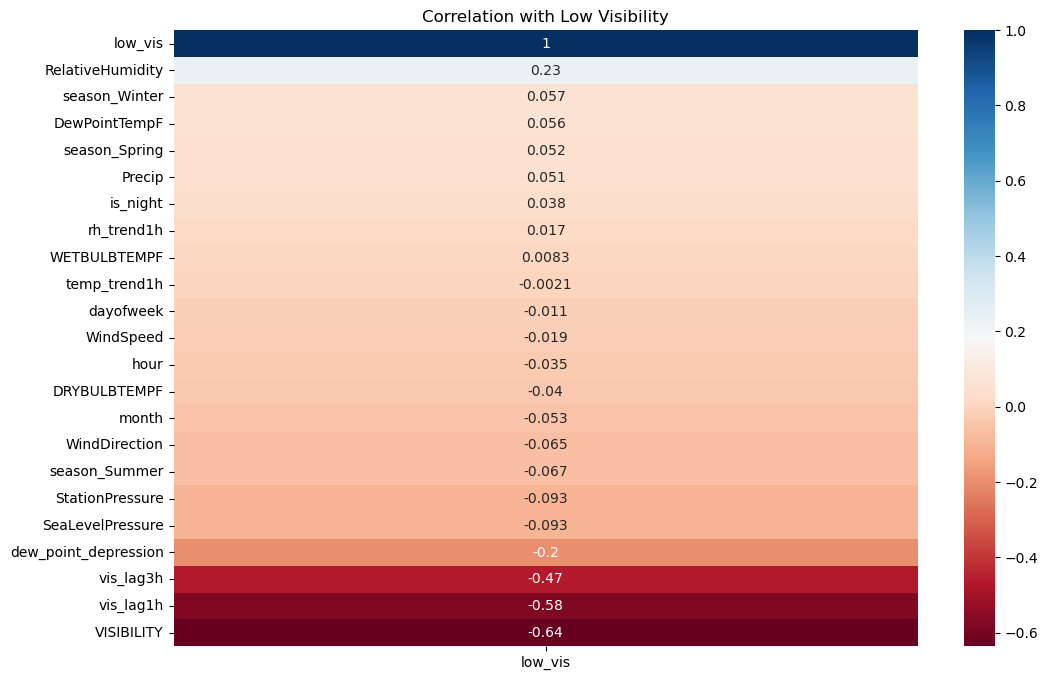

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr()[['low_vis']].sort_values('low_vis', ascending=False), annot=True, cmap='RdBu')
plt.title('Correlation with Low Visibility')
plt.show()

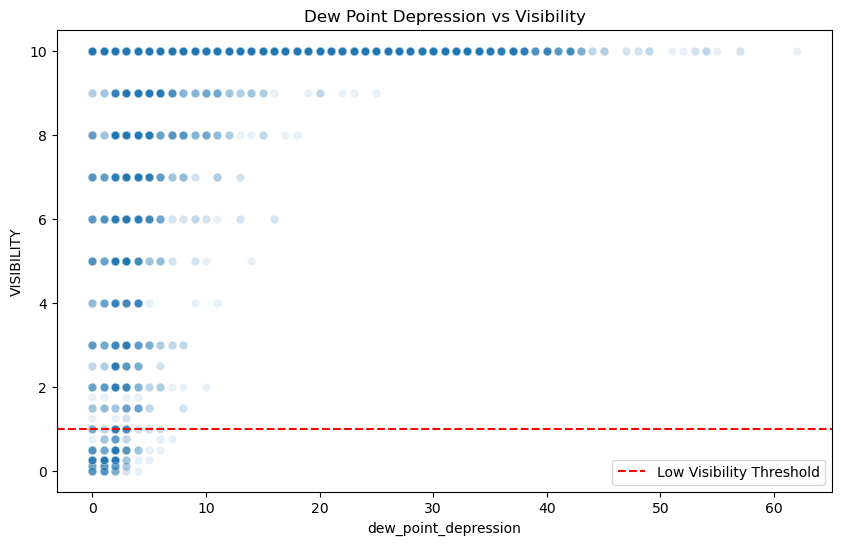

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='dew_point_depression', y='VISIBILITY', data=df.sample(10000), alpha=0.1)
plt.axhline(y=1, color='red', linestyle='--', label='Low Visibility Threshold')
plt.title('Dew Point Depression vs Visibility')
plt.legend()
plt.show()

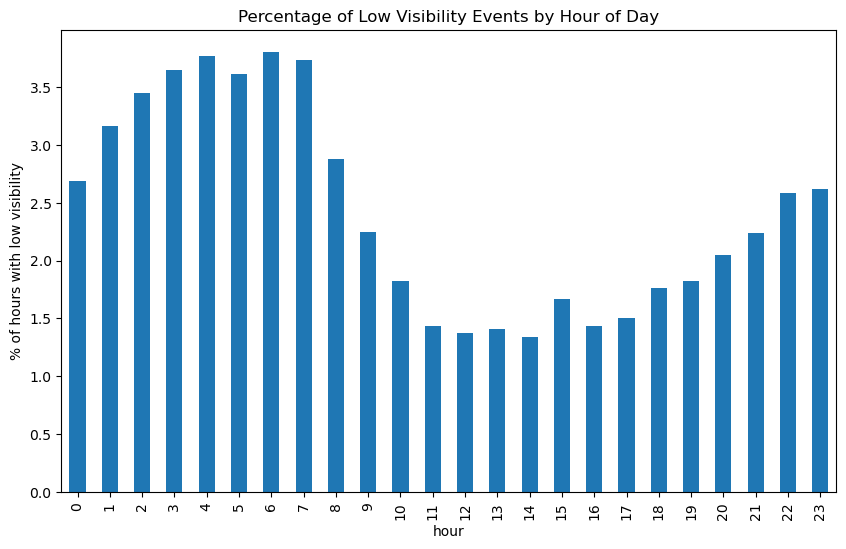

In [26]:
hourly_fog = df.groupby('hour')['low_vis'].mean() * 100
hourly_fog.plot(kind='bar', figsize=(10, 6))
plt.title('Percentage of Low Visibility Events by Hour of Day')
plt.ylabel('% of hours with low visibility')
plt.show()

In [27]:
# Use all data up to 2017 for training, 2017-2018 for testing
split_date = '2017-01-01'

train = df[df.index < split_date]
test = df[df.index >= split_date]

X_train = train.drop(['low_vis', 'VISIBILITY'], axis=1)
y_train = train['low_vis']

X_test = test.drop(['low_vis', 'VISIBILITY'], axis=1)
y_test = test['low_vis']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 61344, Test size: 13739


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])}")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     13354
           1       0.57      0.84      0.68       385

    accuracy                           0.98     13739
   macro avg       0.78      0.91      0.83     13739
weighted avg       0.98      0.98      0.98     13739

ROC AUC: 0.9870411900515241


c:\Users\Win-10\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])}")

XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13354
           1       0.64      0.74      0.69       385

    accuracy                           0.98     13739
   macro avg       0.81      0.87      0.84     13739
weighted avg       0.98      0.98      0.98     13739

ROC AUC: 0.9649323418830683


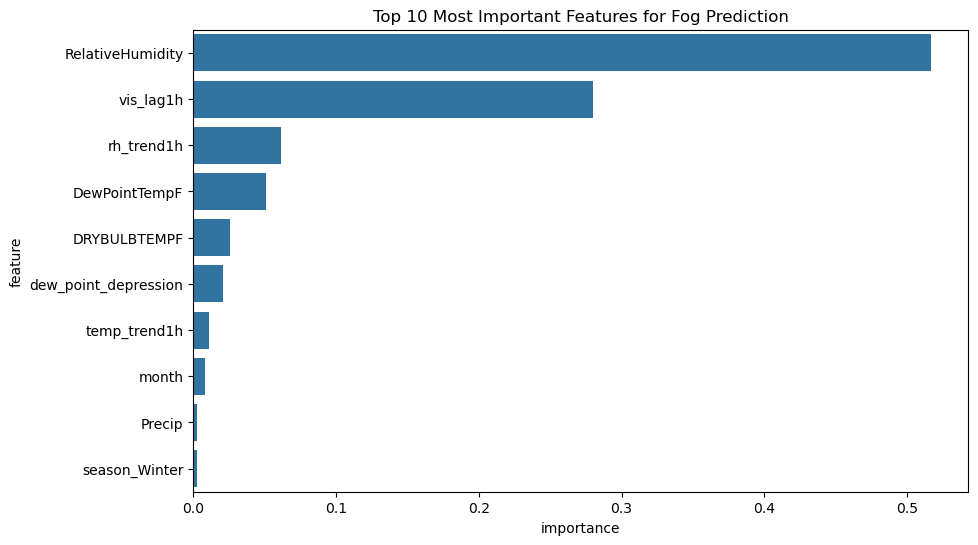

In [31]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features for Fog Prediction')
plt.show()

In [32]:
def predict_fog(current_conditions):
    prob = xgb.predict_proba(current_conditions)[0][1]
    if prob > 0.7:
        return f"🚨 RED ALERT: High chance of fog. Probability: {prob:.1%}"
    elif prob > 0.4:
        return f"⚠️ YELLOW ALERT: Moderate chance of fog. Probability: {prob:.1%}"
    else:
        return f"✅ CLEAR: Low chance of fog. Probability: {prob:.1%}"

# Test it with the most recent data
latest = X_test.iloc[[-1]]
print(predict_fog(latest))

✅ CLEAR: Low chance of fog. Probability: 0.5%


**FINAL MODEL TRAINING**

In [37]:
# Final clean model
features = [
    'RelativeHumidity',
    'DRYBULBTEMPF',
    'DewPointTempF',
    'WindSpeed',
    'hour',
    'dew_point_depression'
]

In [38]:
y = df['low_vis']

In [39]:
split_date = '2017-01-01'

train = df[df.index < split_date]
test = df[df.index >= split_date]

X_train = train[features]
y_train = train['low_vis']

X_test = test[features]
y_test = test['low_vis']

In [40]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=40,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [41]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.81      0.89     13354
           1       0.13      0.97      0.23       385

    accuracy                           0.81     13739
   macro avg       0.56      0.89      0.56     13739
weighted avg       0.97      0.81      0.88     13739



In [44]:
import os
import pickle

base_path = os.path.abspath("..")  # go to root

model_path = os.path.join(base_path, "models", "fog_model.pkl")
features_path = os.path.join(base_path, "models", "features.pkl")

pickle.dump(model, open(model_path, "wb"))
pickle.dump(features, open(features_path, "wb"))

In [45]:
# ==============================
# VISIBILITY MODEL (REGRESSION)
# ==============================

features = [
    'RelativeHumidity',
    'DRYBULBTEMPF',
    'DewPointTempF',
    'WindSpeed',
    'hour',
    'dew_point_depression'
]

X = df[features]
y = df['VISIBILITY']

In [46]:
split_date = '2017-01-01'

train = df[df.index < split_date]
test = df[df.index >= split_date]

X_train = train[features]
y_train = train['VISIBILITY']

X_test = test[features]
y_test = test['VISIBILITY']

In [47]:
from xgboost import XGBRegressor

vis_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1
)

vis_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
from sklearn.metrics import mean_absolute_error

pred = vis_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 1.1552852609067346


In [49]:


os.makedirs("../models", exist_ok=True)

pickle.dump(vis_model, open("../models/visibility_model.pkl", "wb"))